In [ ]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
plt.rcParams["font.size"] = 14
pd.options.display.float_format = "{:.3f}".format

In [ ]:
def get_number_of_instructions(circuit_name: str) -> int:
    with open(f"../../data/circuit/{circuit_name}.in") as f:
        lines = f.readlines()
    return sum(bool(line) for line in lines)

In [ ]:
df = pd.read_csv("../../out/table/Heisenberg2D_10_all.csv")
instruction_count = {c: get_number_of_instructions(c) for c in df["circuit"].unique()}
df["instruction_count"] = df["circuit"].map(instruction_count)
df["cbpi"] = df["total_code_beat"] / df["instruction_count"]
df["architecture"] = df["layer_count"].map({1: "2D", 2: "2.5D"}) + " " + df["factory"]
df["allocator_msf"] = df["allocator"] + " " + df["msf_coeff"].astype(str)
df

,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,circuit_volume,instruction_count,cbpi,architecture,allocator_msf
0,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_0,inner,1,SA,0.001,1,Double,No_MSF,7536,589658,12242,0.616,2D inner,SA 0.001
1,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_0,inner,1,SA,0.001,0,Proj,No_MSF,6660,15572,12242,0.544,2D inner,SA 0.001
2,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_0,inner,1,SA,0.001,0,Proj,No_Top,6660,33396,12242,0.544,2D inner,SA 0.001
3,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_0,inner,1,SA,0.001,0,Double,No_MSF,7536,589658,12242,0.616,2D inner,SA 0.001
4,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_0,inner,1,SA,0.001,0,Single,No_Top,8099,651664,12242,0.662,2D inner,SA 0.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7447,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,2,random,0.000,2,Double,Yes_Kink,900,292942,14760,0.061,2.5D outer,random 0.0
7448,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,2,random,0.000,1,Proj,Yes_Kink,728,417814,14760,0.049,2.5D outer,random 0.0
7449,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,2,random,0.000,2,Single,Yes_Kink,937,277849,14760,0.063,2.5D outer,random 0.0
7450,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,2,random,0.000,2,Proj,No_Kink,965,564020,14760,0.065,2.5D outer,random 0.0


In [ ]:
def extract_best_sa(df):
    idx = df.groupby(
        [
            "circuit",
            "factory",
            "layer_count",
            "allocator",
            "routing_algo",
            "routing_option",
            "msf_prep_time",
        ]
    )["total_code_beat"].idxmin()
    return df.loc[idx]


df_best = extract_best_sa(df)

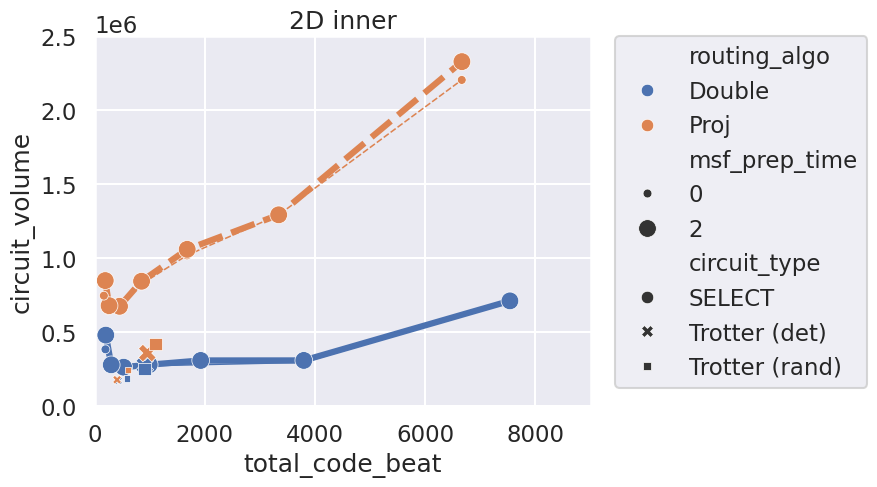

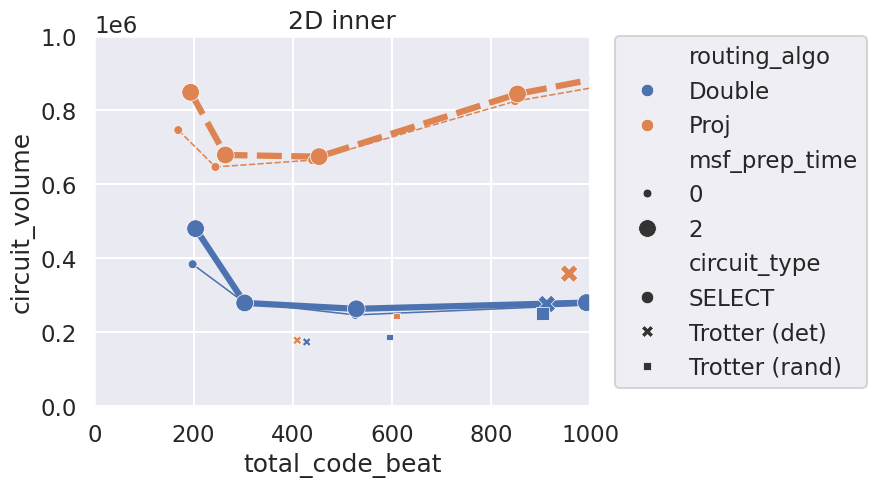

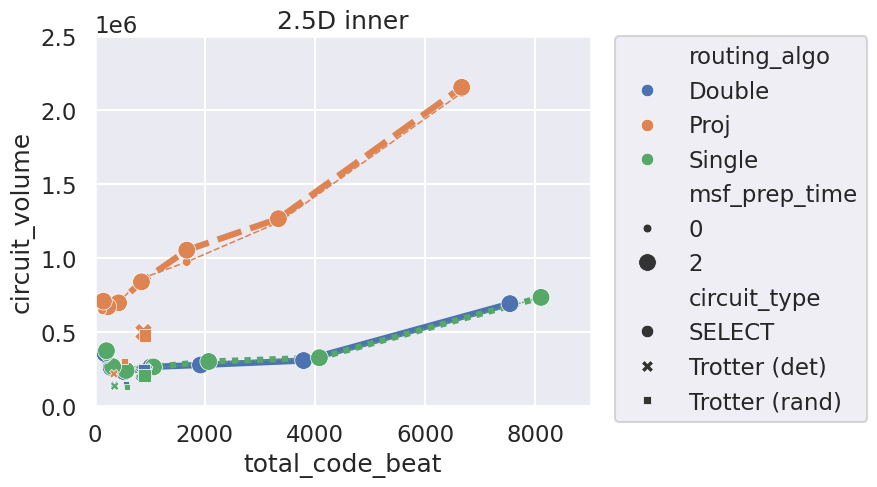

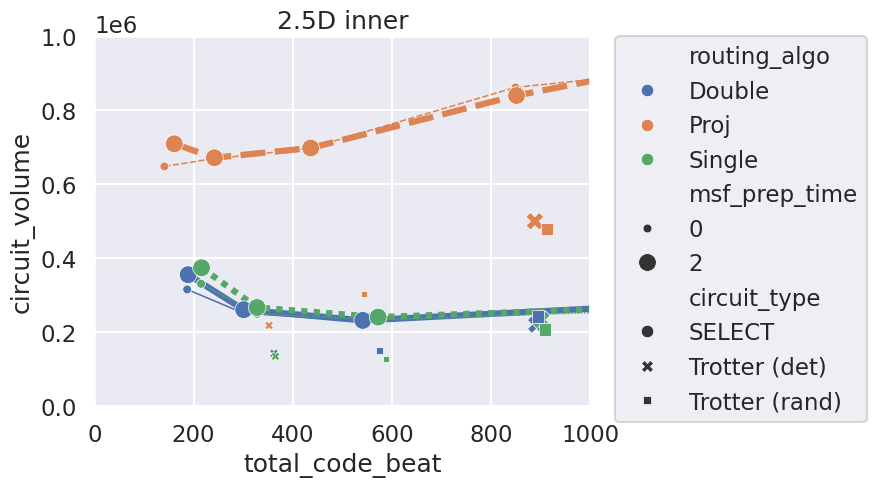

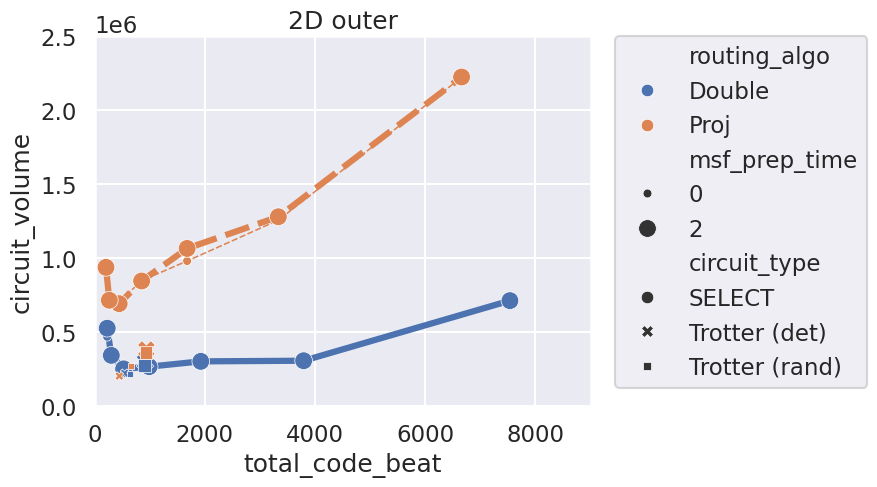

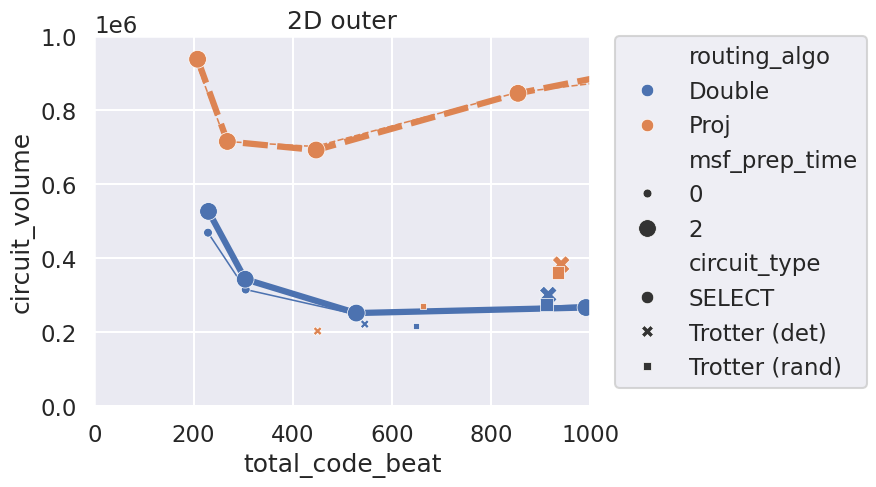

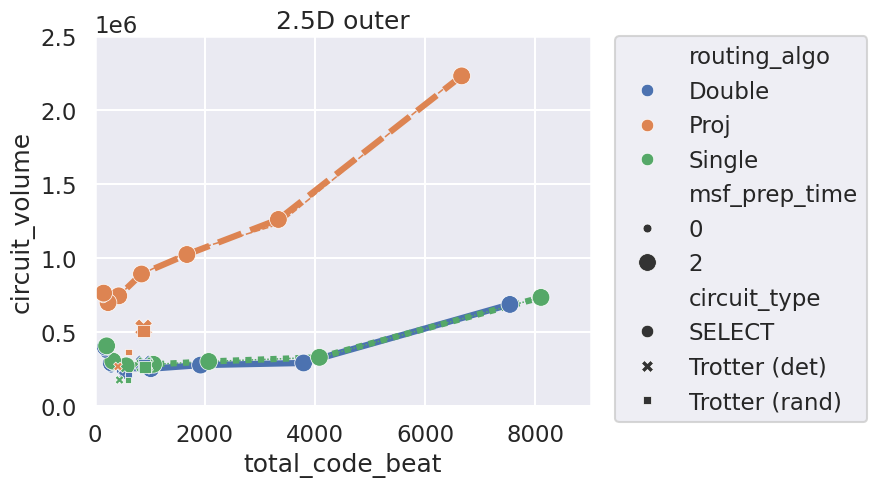

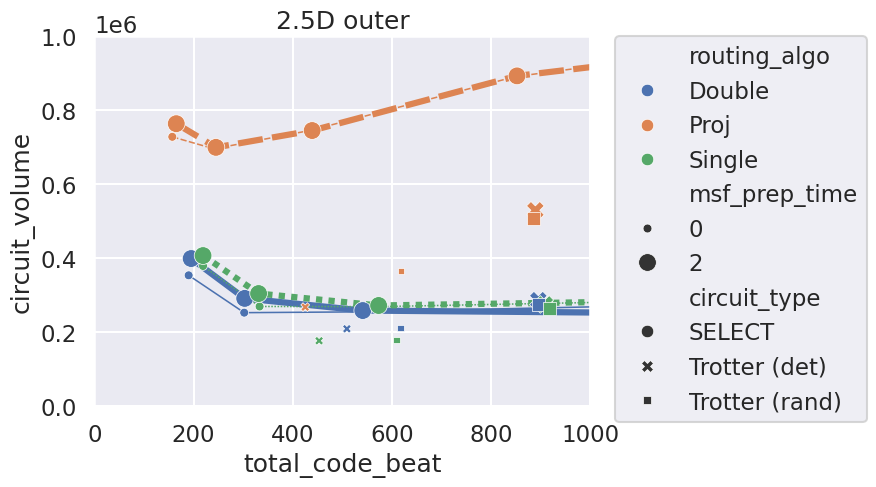

In [ ]:
sns.set_theme("talk")
for factory in ("inner", "outer"):
    for layer_count in (1, 2):
        for show_all in (True, False):
            fig, ax = plt.subplots()
            df_arc = df_best[
                (df_best["routing_option"] == "Yes_Kink")
                & (df_best["allocator"] == "SA")
                & (df_best["factory"] == factory)
                & (df_best["layer_count"] == layer_count)
                & (df_best["msf_prep_time"] != 1)
            ].copy()
            # for routing_algo in ("Double", "Proj"):
            # df_ra = df_arc[df_arc["routing_algo"] == routing_algo]

            splitted_circuit_series = df_arc["circuit"].str.split("_")
            df_arc["circuit_type"] = splitted_circuit_series.map(
                lambda l: "SELECT" if l[1] == "SELECT" else f"Trotter ({l[-1]})"
            )
            df_arc["circuit_suffix"] = splitted_circuit_series.map(lambda l: l[-1])

            # display(df_arc)

            df_select = df_arc[df_arc["circuit_type"] == "SELECT"].copy()
            df_select["parallel"] = df_select["circuit_suffix"].astype(int)
            df_select.sort_values("parallel")
            sns.lineplot(
                df_select,
                x="total_code_beat",
                y="circuit_volume",
                hue="routing_algo",
                style="routing_algo",
                size="msf_prep_time",
                legend=False,
                zorder=1,
            )

            sns.scatterplot(
                df_arc,
                x="total_code_beat",
                y="circuit_volume",
                hue="routing_algo",
                style="circuit_type",
                size="msf_prep_time",
                markers=True,
                zorder=2,
            )

            dim = "2D" if layer_count == 1 else "2.5D"
            ax.set_title(f"{dim} {factory}")
            # ax.set_xscale("log")
            # ax.set_yscale("log")
            ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1), borderaxespad=0)

            if show_all:
                ax.set_xlim(0, 9000)
                ax.set_ylim(0, 2.5e6)
            else:
                ax.set_xlim(0, 1000)
                ax.set_ylim(0, 1e6)
            plt.show()

In [ ]:
# Add single yes kink by doubling no kink


df_single_yes_kink = df_best[
    (df_best["routing_algo"] == "Single") & (df_best["routing_option"] == "No_Kink")
]

df_single_yes_kink["routing_option"] = "Yes_Kink"
df_single_yes_kink["total_code_beat"] *= 2
df_single_yes_kink["circuit_volume"] *= 2
df_single_yes_kink["cbpi"] *= 2

df_best_yes = pd.concat((df_best, df_single_yes_kink))

/tmp/ipykernel_9364/3535494179.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_single_yes_kink["routing_option"] = "Yes_Kink"
/tmp/ipykernel_9364/3535494179.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_single_yes_kink["total_code_beat"] *= 2
/tmp/ipykernel_9364/3535494179.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,circuit_volume,instruction_count,cbpi,architecture,allocator_msf,circuit_type,circuit_suffix
6253,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,0.010,0,Double,No_Kink,454,201049,14754,0.031,2D outer,SA 0.01,Trotter (det),det
6320,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,1.000,0,Proj,No_Kink,436,204503,14754,0.030,2D outer,SA 1.0,Trotter (det),det
6318,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,1.000,0,Single,No_Kink,456,167486,14754,0.031,2D outer,SA 1.0,Trotter (det),det
7140,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,1.000,0,Double,No_Kink,596,188378,14760,0.040,2D outer,SA 1.0,Trotter (rand),rand
7120,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,0.100,0,Proj,No_Kink,650,278867,14760,0.044,2D outer,SA 0.1,Trotter (rand),rand
7080,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,0.010,0,Single,No_Kink,610,171674,14760,0.041,2D outer,SA 0.01,Trotter (rand),rand


,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,circuit_volume,instruction_count,cbpi,architecture,allocator_msf,circuit_type,circuit_suffix
6253,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,0.010,0,Double,No_Kink,454,201049,14754,0.031,2D outer,SA 0.01,Trotter (det),det
6320,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,1.000,0,Proj,No_Kink,436,204503,14754,0.030,2D outer,SA 1.0,Trotter (det),det
6318,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,1.000,0,Single,No_Kink,456,167486,14754,0.031,2D outer,SA 1.0,Trotter (det),det
7140,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,1.000,0,Double,No_Kink,596,188378,14760,0.040,2D outer,SA 1.0,Trotter (rand),rand
7120,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,0.100,0,Proj,No_Kink,650,278867,14760,0.044,2D outer,SA 0.1,Trotter (rand),rand
7080,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,outer,1,SA,0.010,0,Single,No_Kink,610,171674,14760,0.041,2D outer,SA 0.01,Trotter (rand),rand


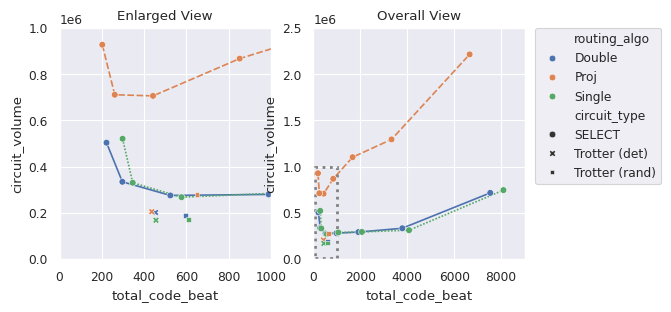

In [71]:
import matplotlib.patches as patches

sns.set_theme("paper")

ENLARGED_MAX_X = 1000
ENLARGED_MAX_Y = 1e6

OVERALL_MAX_X = 9000
OVERALL_MAX_Y = 2.5e6

factory = "outer"
layer_count = 1
fig, axes = plt.subplots(ncols=2, figsize=(6, 3))
for show_all, ax in zip((False, True), axes):
    df_arc = df_best_yes[
        (df_best_yes["routing_option"] == "No_Kink")
        & (df_best_yes["allocator"] == "SA")
        & (df_best_yes["factory"] == factory)
        & (df_best_yes["layer_count"] == layer_count)
        & (df_best_yes["msf_prep_time"] != 1)
    ].copy()

    # for routing_algo in ("Double", "Proj"):
    # df_ra = df_arc[df_arc["routing_algo"] == routing_algo]

    splitted_circuit_series = df_arc["circuit"].str.split("_")
    df_arc["circuit_type"] = splitted_circuit_series.map(
        lambda l: "SELECT" if l[1] == "SELECT" else f"Trotter ({l[-1]})"
    )
    df_arc["circuit_suffix"] = splitted_circuit_series.map(lambda l: l[-1])

    # display(df_arc)

    df_select = df_arc[
        (df_arc["circuit_type"] == "SELECT") & (df_arc["msf_prep_time"] == 2)
    ].copy()
    df_select["parallel"] = df_select["circuit_suffix"].astype(int)
    df_select.sort_values("parallel")
    df_trotter = df_arc[
        (df_arc["circuit_type"] != "SELECT") & (df_arc["msf_prep_time"] == 0)
    ].copy()

    display(df_trotter)

    sns.lineplot(
        df_select,
        x="total_code_beat",
        y="circuit_volume",
        hue="routing_algo",
        style="routing_algo",
        legend=False,
        zorder=1,
        ax=ax,
    )

    sns.scatterplot(
        pd.concat((df_select, df_trotter)),
        x="total_code_beat",
        y="circuit_volume",
        hue="routing_algo",
        style="circuit_type",
        legend=show_all,
        markers=True,
        zorder=2,
        ax=ax,
    )

    dim = "2D" if layer_count == 1 else "2.5D"
    ax.set_title("Overall View" if show_all else "Enlarged View")
    # ax.set_xscale("log")
    # ax.set_yscale("log")

    if show_all:
        ax.set_xlim(0, 9000)
        ax.set_ylim(0, 2.5e6)
    else:
        ax.set_xlim(0, ENLARGED_MAX_X)
        ax.set_ylim(0, ENLARGED_MAX_Y)

ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1), borderaxespad=0)
half_line_width_x = OVERALL_MAX_X * 0.007
half_line_width_y = OVERALL_MAX_Y * 0.005
ax.add_patch(
    patches.Rectangle(
        xy=(half_line_width_x, half_line_width_y),
        width=ENLARGED_MAX_X - half_line_width_x,
        height=ENLARGED_MAX_Y - half_line_width_y,
        fill=False,
        linestyle=":",
        edgecolor="gray",
        linewidth=2,
    )
)
plt.show()